# Microsft Bing Image Search Download

Using Microsoft Bing to download images of different foods.

Source: https://docs.microsoft.com/en-us/azure/cognitive-services/bing-image-search/quickstarts/python

**Note:** The docs link above says to use `"https://api.cognitive.microsoft.com/bing/v7.0/images/search"` as the search API URL but due to API changes, the correct link to use is `"https://api.bing.microsoft.com/v7.0/images/search"`. This is true for API instances made after October 30, 2020.

In [1]:
import requests
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
import streamlit as st

# subscription_key = st.secrets["pexels_api_key"]
try:
    API_KEY = st.secrets["pexels_api_key"]
except Exception:
    import tomllib  # Fallback for manual local parsing
    with open(SECRETS_PATH, "rb") as f:
        config = tomllib.load(f)
        API_KEY = config["pexels_api_key"]

# search_url = "https://api.cognitive.microsoft.com/bing/v7.0/images/search" # OLD
search_url = "https://api.pexels.com/v1/search" # New (after Oct 30, 2020)


In [5]:
headers = {"Authorization" : API_KEY}

## Create and send a search request

In [6]:
search_term = "apple"

# See list of params here - https://docs.microsoft.com/en-us/bing/search-apis/bing-image-search/reference/query-parameters 
params = {
    "query": search_term,
    "per_page": 16 # This tells Pexels to just return 16 images directly
}

In [7]:
response = requests.get(search_url, headers=headers, params=params)
response.raise_for_status() # used for debugging
search_results = response.json()

# Pexels stores the list in 'photos' and the image sizes in 'src'
thumbnail_urls = [img["src"]["medium"] for img in search_results["photos"]]

In [8]:
search_results

{'page': 1,
 'per_page': 16,
 'photos': [{'id': 34282667,
   'width': 3500,
   'height': 5260,
   'url': 'https://www.pexels.com/photo/autumn-apple-harvest-in-aberfeldy-orchard-34282667/',
   'photographer': 'Jilly Noble',
   'photographer_url': 'https://www.pexels.com/@jillyjillystudio',
   'photographer_id': 3459546,
   'avg_color': '#875D44',
   'src': {'original': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg',
    'large2x': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg?auto=compress&cs=tinysrgb&dpr=2&h=650&w=940',
    'large': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg?auto=compress&cs=tinysrgb&h=650&w=940',
    'medium': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg?auto=compress&cs=tinysrgb&h=350',
    'small': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg?auto=compress&cs=tinysrgb&h=130',
    'portrait': 'https://images.pexels.com/photos/34282667/pexels-ph

In [10]:
# The length of "value" parameter will be set by the "count" parameter:
# see: https://docs.microsoft.com/en-us/bing/search-apis/bing-image-search/reference/query-parameters
# Min: 35, Max: 150
len(search_results["photos"])

16

In [12]:
search_results["photos"][0]

{'id': 34282667,
 'width': 3500,
 'height': 5260,
 'url': 'https://www.pexels.com/photo/autumn-apple-harvest-in-aberfeldy-orchard-34282667/',
 'photographer': 'Jilly Noble',
 'photographer_url': 'https://www.pexels.com/@jillyjillystudio',
 'photographer_id': 3459546,
 'avg_color': '#875D44',
 'src': {'original': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg',
  'large2x': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg?auto=compress&cs=tinysrgb&dpr=2&h=650&w=940',
  'large': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg?auto=compress&cs=tinysrgb&h=650&w=940',
  'medium': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg?auto=compress&cs=tinysrgb&h=350',
  'small': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg?auto=compress&cs=tinysrgb&h=130',
  'portrait': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg?auto=compress&cs=tinysrgb&fit=crop&h=1200&w=800',

In [13]:
# We can save metadata from our image so we can look it up later
attributes_from_value = ["width", "height", "contentURL"] 
attributes_to_create = ["date_created", "source"]

In [14]:
# Get current time
import datetime
current_time = datetime.datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            )
current_time

'2026-07-06 22:47:11'

## View images

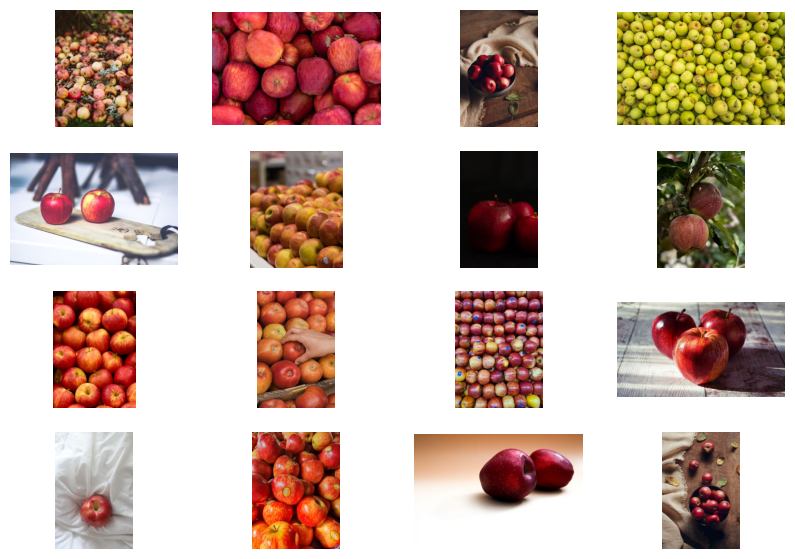

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(10, 7))
for i in range(4):
    for j in range (4):
        image_data = requests.get(thumbnail_urls[i+4*j]) # downloads as bytes
        image_data.raise_for_status()
        image = Image.open(BytesIO(image_data.content))
        axes[i][j].imshow(image)
        axes[i][j].axis("off")
plt.show()

## Downloading an image

In [16]:
image = requests.get("https://pixnio.com/free-images/2017/11/10/2017-11-10-21-27-56.jpg")
open("downloaded_img.jpg", "wb").write(image.content)

1242

## Getting URLs for multiple images (for different search terms)

Let's write some code to get a bunch of images downloaded (we can turn the following into a script later).

In [18]:
# # Original search terms
search_terms = ['apple',
 'banana',
 'beef',
 'blueberries',
 'carrots',
 'chicken_wings',
 'egg',
 'honey',
 'mushrooms',
 'strawberries']

# New search terms (V2)
# search_terms = ['Apple',
#  'Artichoke',
#  'BBQ sauce',
#  'Bacon',
#  'Bagel',
#  'Banana',
#  'Beef',
#  'Beer',
#  'Blueberries',
#  'Bread',
#  'Broccoli',
#  'Butter',
#  'Cabbage',
#  'Candy',
#  'Cantaloupe',
#  'Carrot',
#  'Carrots',
#  'Cheese',
#  'Chicken',
#  'Chicken wings',
#  'Cocktail',
#  'Coconut',
#  'Coffee',
#  'Cookie',
#  'Corn chips',
#  'Cream',
#  'Cucumber',
#  'Dessert',
#  'Doughnut',
#  'Egg',
#  'Fish',
#  'Fries',
#  'Grape',
#  'Guacamole',
#  'Hamburger',
#  'Honey',
#  'Ice cream',
#  'Juice',
#  'Lemon',
#  'Lime',
#  'Lobster',
#  'Mango',
#  'Milk',
#  'Muffin',
#  'Mushroom',
#  'Mushrooms',
#  'Olive oil',
#  'Olives',
#  'Onion',
#  'Orange',
#  'Orange juice',
#  'Pancake',
#  'Pasta',
#  'Pastry',
#  'Pear',
#  'Pepper',
#  'Pineapple',
#  'Pizza',
#  'Pomegranate',
#  'Popcorn',
#  'Potato',
#  'Prawns',
#  'Pretzel',
#  'Pumpkin',
#  'Radish',
#  'Rice',
#  'Rose',
#  'Salad',
#  'Salt',
#  'Sandwich',
#  'Sausages',
#  'Seafood',
#  'Shellfish',
#  'Soft drink',
#  'Spinach',
#  'Squid',
#  'Strawberries',
#  'Strawberry',
#  'Sushi',
#  'Tea',
#  'Tomato',
#  'Tomato sauce',
#  'Vegetable',
#  'Waffle',
#  'Watermelon',
#  'Wine',
#  'Zucchini']

In [19]:
import requests
import matplotlib.pyplot as plt
import streamlit as st

from PIL import Image
from io import BytesIO

API_KEY = st.secrets["pexels_api_key"]
SEARCH_URL = "https://api.bing.microsoft.com/v7.0/images/search"

# Number of images per page
# COUNT = 150 # min 35, max 150, see "count" - https://docs.microsoft.com/en-us/bing/search-apis/bing-image-search/reference/query-parameters
COUNT = 80  # Pexels API caps a single query request at 80 max

headers = {"Ocp-Apim-Subscription-Key" : API_KEY}

# TODO
* Batch save images
* Batch delete images
* Add image metadata to CSV (for logging and exporting later)

In [20]:
import uuid
import datetime
import requests

# 1. Force this cell to use Pexels instead of Bing
SEARCH_URL = "https://api.pexels.com/v1/search"
headers = {"Authorization": st.secrets["pexels_api_key"]}

img_to_download_list = []
for search_term in search_terms:

    # Fixed a minor bug here so it prints the actual word instead of the literal string 'search_term'
    print(f"\n[INFO] Searching for '{search_term}' images...")
    
    # 2. Update parameters for Pexels ('query' instead of 'q', 'per_page' instead of 'count')
    # Note: Pexels allows a maximum COUNT of 80 per request
    params = {
        "query": search_term,
        "per_page": COUNT 
    }
    
    response = requests.get(SEARCH_URL, 
                            headers=headers, 
                            params=params)
    response.raise_for_status() # used for debugging
    search_results = response.json()

    # 3. Pexels uses 'total_results' instead of 'totalEstimatedMatches'
    print(f"[INFO] Found {search_results['total_results']} potential image matches...")
    print("[INFO] Appending image URLs to dictionary... \n")
    
    # 4. Pexels stores the list of images in 'photos' instead of 'value'
    for i, value in enumerate(search_results["photos"]):
        img_metadata = {}

        # Give each image a UUID
        img_metadata["image_id"] = str(uuid.uuid4())

        # State the source of the image
        img_metadata["source"] = "pexels_api_v1"
        
        # Collect metadata about each image
        img_metadata["search_term"] = search_term
        
        # 5. Pexels nests image URLs inside a 'src' dictionary. 
        # Using 'original' gets you the full high-res image.
        img_metadata["img_url"] = value["src"]["original"] 
        img_metadata["height"] = value["height"]
        img_metadata["width"] = value["width"]
        img_metadata["time_downloaded"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        
        img_to_download_list.append(img_metadata)
        if i % 50 == 0:
            print(f"[INFO] Adding image url for '{search_term}': {img_metadata['img_url']}...")

img_to_download_list


[INFO] Searching for 'apple' images...
[INFO] Found 6296 potential image matches...
[INFO] Appending image URLs to dictionary... 

[INFO] Adding image url for 'apple': https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg...
[INFO] Adding image url for 'apple': https://images.pexels.com/photos/15091746/pexels-photo-15091746.jpeg...

[INFO] Searching for 'banana' images...
[INFO] Found 5835 potential image matches...
[INFO] Appending image URLs to dictionary... 

[INFO] Adding image url for 'banana': https://images.pexels.com/photos/37182860/pexels-photo-37182860.jpeg...
[INFO] Adding image url for 'banana': https://images.pexels.com/photos/31680011/pexels-photo-31680011.jpeg...

[INFO] Searching for 'beef' images...
[INFO] Found 5252 potential image matches...
[INFO] Appending image URLs to dictionary... 

[INFO] Adding image url for 'beef': https://images.pexels.com/photos/6545671/pexels-photo-6545671.jpeg...
[INFO] Adding image url for 'beef': https://images.pexels.co

[{'image_id': 'bb485d7a-71d2-4a21-a909-b2561a53362e',
  'source': 'pexels_api_v1',
  'search_term': 'apple',
  'img_url': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg',
  'height': 5260,
  'width': 3500,
  'time_downloaded': '2026-07-06 22:48:02'},
 {'image_id': '3063de25-58f6-498c-9f0e-f80007bc2fb6',
  'source': 'pexels_api_v1',
  'search_term': 'apple',
  'img_url': 'https://images.pexels.com/photos/5960/healthy-wood-red-apple.jpg',
  'height': 3648,
  'width': 5472,
  'time_downloaded': '2026-07-06 22:48:02'},
 {'image_id': '214b6f8d-d09f-43f0-bbb1-9fa7fbc63f99',
  'source': 'pexels_api_v1',
  'search_term': 'apple',
  'img_url': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg',
  'height': 3316,
  'width': 2339,
  'time_downloaded': '2026-07-06 22:48:02'},
 {'image_id': 'ccc53364-ac14-448e-8b52-5fc31dab64a5',
  'source': 'pexels_api_v1',
  'search_term': 'apple',
  'img_url': 'https://images.pexels.com/photos/5498207/pexels-photo-54982

In [21]:
import pandas as pd
targ_img_df = pd.DataFrame(img_to_download_list)
targ_img_df

,image_id,source,search_term,img_url,height,width,time_downloaded
0,bb485d7a-71d2-4a21-a909-b2561a53362e,pexels_api_v1,apple,https://images.pexels.com/photos/34282667/pexe...,5260,3500,2026-07-06 22:48:02
1,3063de25-58f6-498c-9f0e-f80007bc2fb6,pexels_api_v1,apple,https://images.pexels.com/photos/5960/healthy-...,3648,5472,2026-07-06 22:48:02
2,214b6f8d-d09f-43f0-bbb1-9fa7fbc63f99,pexels_api_v1,apple,https://images.pexels.com/photos/28710026/pexe...,3316,2339,2026-07-06 22:48:02
3,ccc53364-ac14-448e-8b52-5fc31dab64a5,pexels_api_v1,apple,https://images.pexels.com/photos/5498207/pexel...,5000,4000,2026-07-06 22:48:02
4,b71a66fe-0568-424d-863c-9d836bee53ce,pexels_api_v1,apple,https://images.pexels.com/photos/14833258/pexe...,4975,3317,2026-07-06 22:48:02
...,...,...,...,...,...,...,...
795,d76ab686-6fe0-4979-acce-9c648a02367a,pexels_api_v1,strawberries,https://images.pexels.com/photos/30246929/pexe...,5184,3456,2026-07-06 22:48:24
796,afcbfe93-2fa0-4fa9-a16b-915ff49aaf7c,pexels_api_v1,strawberries,https://images.pexels.com/photos/24595915/pexe...,7500,10000,2026-07-06 22:48:24
797,40225ebb-60bf-49c3-92ff-626b97703d33,pexels_api_v1,strawberries,https://images.pexels.com/photos/20329366/pexe...,5767,3845,2026-07-06 22:48:24
798,5d9e13dd-6aca-49b6-9d25-2ddc74a27a3d,pexels_api_v1,strawberries,https://images.pexels.com/photos/37354949/pexe...,6240,4160,2026-07-06 22:48:24


In [22]:
import os

# # Create the 'data' directory if it doesn't exist yet
# os.makedirs("data", exist_ok=True)

# # Save the dataframe to the CSV
# targ_img_df.to_csv("data/100_target_images_metadata.csv", index=False)

BASE_DIR = r"C:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\data_exploration\data"
SECRETS_PATH = r"C:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\.streamlit\secrets.toml"
TARG_DIR = os.path.join(BASE_DIR, "100_foods")

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(TARG_DIR, exist_ok=True)

In [23]:
len(targ_img_df)

800

## Downloading data for multiple URLs

Now we have a bunch of URLs, let's download data.

In [25]:
# List of exceptions, source: https://www.pyimagesearch.com/2018/04/09/how-to-quickly-build-a-deep-learning-image-dataset/
from requests import exceptions
EXCEPTIONS = set([IOError, FileNotFoundError,
	exceptions.RequestException, exceptions.HTTPError,
	exceptions.ConnectionError, exceptions.Timeout])

In [26]:
img_to_download_list[0]

{'image_id': 'bb485d7a-71d2-4a21-a909-b2561a53362e',
 'source': 'pexels_api_v1',
 'search_term': 'apple',
 'img_url': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg',
 'height': 5260,
 'width': 3500,
 'time_downloaded': '2026-07-06 22:48:02'}

## Download images

In [27]:
import os
import uuid

TARG_DIR = "data/100_foods"
if not os.path.exists(TARG_DIR):
    print(f"[INFO] Making directory: {TARG_DIR}...")
    os.makedirs(TARG_DIR, exist_ok=True)
else:
    print(f"[INFO] Directory '{TARG_DIR}' exists, skipping creation...")

# Make target dirs
for search_term in search_terms: 
    os.makedirs(os.path.join(TARG_DIR, search_term))

# Download images...
print(f"Attempting to download {len(img_to_download_list)} images... \n")
for i, img_dict in enumerate(img_to_download_list):
    i += 1
    img_id = img_dict["image_id"]
    img_url = img_dict["img_url"]
    search_term = img_dict["search_term"]
    try:
        # Get the image
        img_data = requests.get(img_url, timeout=30)

        # Write image to file
        class_dir = os.path.join(TARG_DIR, search_term)
        save_path = os.path.join(class_dir, 
                                 img_id + ".jpg")
        # f = open(save_path, "wb")
        # f.write(img_data.content)
        # f.close()
        img_data.raise_for_status() # Catches bad status codes before writing files
        with open(save_path, "wb") as f:
            f.write(img_data.content)
    
    # If the image doesn't download, skip it 
    except Exception as e:
        if type(e) in EXCEPTIONS:
            print(f"Skipping image: {img_url} due to exception: {e}")
            continue    

    if i % 50 == 0:
        print(f"Images downloaded successfully for {search_term}: {len(os.listdir(class_dir))}")

[INFO] Making directory: data/100_foods...
Attempting to download 800 images... 

Images downloaded successfully for apple: 50
Skipping image: https://images.pexels.com/photos/16214622/pexels-photo-16214622.jpeg due to exception: 422 Client Error: Unprocessable Entity for url: https://images.pexels.com/photos/16214622/pexels-photo-16214622.jpeg
Images downloaded successfully for banana: 19
Images downloaded successfully for banana: 69
Images downloaded successfully for beef: 40
Images downloaded successfully for blueberries: 10
Images downloaded successfully for blueberries: 60
Images downloaded successfully for carrots: 30
Images downloaded successfully for carrots: 80
Images downloaded successfully for chicken_wings: 50
Images downloaded successfully for egg: 20
Images downloaded successfully for egg: 70
Images downloaded successfully for honey: 40
Images downloaded successfully for mushrooms: 10
Images downloaded successfully for mushrooms: 60
Images downloaded successfully for stra

## TODO: Delete images that don't work

TODO:
* Scan through downloaded images and if they don't work, delete them.
    * See this for scanning through directories to get subpath names: https://stackoverflow.com/a/2909998/7900723
* Also delete them from the CSV metadata file.

```python
# Pseudocode
for img_path in img_paths:
    try:
        open(img_path)

    # If it doesn't open, delete the image...
    except:
        os.remove(img_path)
        # CODE HERE TO DELTE FROM CSV FILE AS WELL???
        continue
```

In [28]:
import os
import pathlib # see here for more on PathLib - https://realpython.com/python-pathlib/
img_files_to_check = []
for path, subdirs, files in os.walk(TARG_DIR):
    for name in files:
        # print(name.split(".")[0])
        img_files_to_check.append(pathlib.Path(path, name))


In [29]:
# .stem gets the filename from a PosixPath (Path datatype) 
img_files_to_check[0].stem

'0003b405-ecdf-4396-8231-a9c1ed5bd673'

In [30]:
broken_images = []
for img_file_path in img_files_to_check:
    # Check images downloaded and delete if bogus
    # try:
    #     image_id = img_file_path.stem # get image id
    #     Image.open(img_file_path) # if this fails, the target image should be deleted... 
    # except Exception as e:
    #     broken_images.append(image_id)
    #     print(f"Image: {image_id} is broken because: {e}...")
    #     print(f"Deleting image... total images removed: {len(broken_images)}")
    #     os.remove(img_file_path)
            # continue
    try:
        image_id = img_file_path.stem
        with Image.open(img_file_path) as img:
            img.verify() # Validates internal byte alignment safely
    except Exception as e:
        broken_images.append(image_id)
        print(f"Image: {image_id} is broken because: {e}...")
        try:
            os.remove(img_file_path) # Deletes without system file-lock conflicts
        except OSError:
            pass


c:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\food-vision\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (108576768 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
c:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\food-vision\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (103534296 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [31]:
broken_images[:10]

[]

This error occurs when PIL.Image can't open a file:

```
UnidentifiedImageError: cannot identify image file '10_whole_foods_test/apple/47a052b0-c5ee-4e42-9352-0b4f278d0e6d.jpg'
```

So we can use an exception to skip/delete it when it comes across it.

UPTOHERE:

another error appears...

```
Deleting image: 10_whole_foods_test/banana/1d5388dd-01c2-4aae-b7b0-d09f0e7e67f6.jpg due to cannot identify image file '10_whole_foods_test/banana/1d5388dd-01c2-4aae-b7b0-d09f0e7e67f6.jpg'...
Deleting image: 10_whole_foods_test/banana/1d5388dd-01c2-4aae-b7b0-d09f0e7e67f6.jpg due to [Errno 2] No such file or directory: '10_whole_foods_test/banana/1d5388dd-01c2-4aae-b7b0-d09f0e7e67f6.jpg'...
```

Looks like it doubled up on itself? 

Could remove that code and then check the directory once it's done and delete any images that are corrupt:

1. Save all images to directory (batch save)
2. Scan all saved images and delete if corrupt (batch delete)
3. Move to next class...

```python
 Check images downloaded and delete if bogus
        try:
            Image.open(save_path)
            
        except Exception as e:
            print(f"Deleting image: {save_path} due to {e}...")
            os.remove(save_path)
            continue
```

## TODO: Update metadata to reflect deleted images

In [32]:
print("1. Search terms:", search_terms)
print("2. Total images collected in list:", len(img_to_download_list))
print("3. DataFrame rows and columns:", targ_img_df.shape)

1. Search terms: ['apple', 'banana', 'beef', 'blueberries', 'carrots', 'chicken_wings', 'egg', 'honey', 'mushrooms', 'strawberries']
2. Total images collected in list: 800
3. DataFrame rows and columns: (800, 7)


In [33]:
import pandas as pd
targ_img_df = pd.DataFrame(img_to_download_list)

In [34]:
targ_img_df.head()

,image_id,source,search_term,img_url,height,width,time_downloaded
0,bb485d7a-71d2-4a21-a909-b2561a53362e,pexels_api_v1,apple,https://images.pexels.com/photos/34282667/pexe...,5260,3500,2026-07-06 22:48:02
1,3063de25-58f6-498c-9f0e-f80007bc2fb6,pexels_api_v1,apple,https://images.pexels.com/photos/5960/healthy-...,3648,5472,2026-07-06 22:48:02
2,214b6f8d-d09f-43f0-bbb1-9fa7fbc63f99,pexels_api_v1,apple,https://images.pexels.com/photos/28710026/pexe...,3316,2339,2026-07-06 22:48:02
3,ccc53364-ac14-448e-8b52-5fc31dab64a5,pexels_api_v1,apple,https://images.pexels.com/photos/5498207/pexel...,5000,4000,2026-07-06 22:48:02
4,b71a66fe-0568-424d-863c-9d836bee53ce,pexels_api_v1,apple,https://images.pexels.com/photos/14833258/pexe...,4975,3317,2026-07-06 22:48:02


In [35]:
# Remove broken images from targ_img_df
# Look at the targ img df and filter for images "not in" the broken images
targ_img_df_good = targ_img_df[~targ_img_df["image_id"].isin(broken_images)]
targ_img_df_good.head()

,image_id,source,search_term,img_url,height,width,time_downloaded
0,bb485d7a-71d2-4a21-a909-b2561a53362e,pexels_api_v1,apple,https://images.pexels.com/photos/34282667/pexe...,5260,3500,2026-07-06 22:48:02
1,3063de25-58f6-498c-9f0e-f80007bc2fb6,pexels_api_v1,apple,https://images.pexels.com/photos/5960/healthy-...,3648,5472,2026-07-06 22:48:02
2,214b6f8d-d09f-43f0-bbb1-9fa7fbc63f99,pexels_api_v1,apple,https://images.pexels.com/photos/28710026/pexe...,3316,2339,2026-07-06 22:48:02
3,ccc53364-ac14-448e-8b52-5fc31dab64a5,pexels_api_v1,apple,https://images.pexels.com/photos/5498207/pexel...,5000,4000,2026-07-06 22:48:02
4,b71a66fe-0568-424d-863c-9d836bee53ce,pexels_api_v1,apple,https://images.pexels.com/photos/14833258/pexe...,4975,3317,2026-07-06 22:48:02


In [36]:
len(targ_img_df_good)

800

## Verify that images in saved folder are in metadata csv

In [38]:
# !rm 10_whole_foods_test/.DS_Store

In [39]:
TARG_DIR

'data/100_foods'

In [40]:
# Get list of saved images 
import os
import pathlib # see here for more on PathLib - https://realpython.com/python-pathlib/
saved_image_ids = []
for path, subdirs, files in os.walk(TARG_DIR):
    for name in files:
        # print(name.split(".")[0])
        saved_image_ids.append(pathlib.Path(path, name).stem)
saved_image_ids[:10]

['0003b405-ecdf-4396-8231-a9c1ed5bd673',
 '005461f1-066f-4e4d-9542-6090d91f7551',
 '0c912d33-d14f-41f5-bc83-1e4d77b71ec6',
 '109e61a8-c26d-4b6c-ae26-431ef24bfabc',
 '11eb7749-eea1-4d93-aea9-bb98d79add4f',
 '18a5fc35-6a55-4b74-9647-6a6c2a97eeeb',
 '18c99ccc-d8ff-47b0-ac0b-b816c7118124',
 '1ef253f5-4599-41a3-aeb4-65d7cfa5f52b',
 '214b6f8d-d09f-43f0-bbb1-9fa7fbc63f99',
 '21bef7de-4fb0-4621-a4bf-61157dce27c1']

In [41]:
print(len(targ_img_df_good))
targ_img_df_good = targ_img_df_good[targ_img_df_good["image_id"].isin(saved_image_ids)]
print(len(targ_img_df_good))

800
799


In [42]:
assert sorted(saved_image_ids) == sorted(targ_img_df_good.image_id.tolist())

## Export the metadata CSV for later use

In [43]:
targ_img_df_good.to_csv("data/100_foods_metadata_updated.csv")